# L16b Lab: Continuous LavaWorld with Deep Q-Learning
Last semester in CHEME-5800 we solved the [LavaWorld grid problem](../../../../../../CHEME-5800-Fall-2025/CHEME-5800-Lectures-Fall-2025/lectures/week-13/L13a/CHEME-5800-L13a-Example-LavaWorldProblem-Q-Learning-Fall-2025.ipynb) with tabular Q-learning: a robot picked one of four moves, the position was a discrete cell index, and the Q-table was just a `(nstates, 4)` matrix. That worked because the world was a $30\times 30$ grid, $900$ states. The moment we replace the integer position with a *continuous* position and add velocity, the state space becomes $\mathbb{R}^{4}$, the table blows up, and tabular Q-learning is dead. This is the curse of dimensionality the L16a lecture warned about, and it is exactly the regime DQN was built for.

__Problem statement.__ A robot lives on a continuous $L_{x}\times L_{y}$ board with state $\mathbf{s} = (x, y, v_{x}, v_{y})\in\mathbb{R}^{4}$. The robot has momentum and drag, and at each step it picks one of five thrust actions (`+x`, `−x`, `+y`, `−y`, `coast`) which adds to the velocity, with Gaussian actuator noise. Lava pits are scattered across the board (terminal, large negative reward); a charger sits in one corner (terminal, large positive reward); every other step pays a small step cost. The goal is to learn a policy $\pi:\mathbb{R}^{4}\to\mathcal{A}$ that gets the robot to the charger from any starting state without driving into lava, using Deep Q-Learning with a replay buffer and a delayed target network.

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Build a continuous-state RL environment from scratch:__ Write a `world(s, a, context)` step function that integrates a noisy point-mass with drag, encodes terminal lava and charger conditions as a `done` flag, and returns the Q-learning tuple `(s′, r, done)` consumed by the DQN update.
> * __Assemble and train a DQN agent:__ Construct a Flux main Q-network and an identical target network, wire them together with a circular replay buffer of `(s, a, r, s′, done)` tuples inside a `MyDQNLearningAgentModel`, and run the DQN training loop with a $t^{-1/3}$ ε-greedy schedule until the per-episode return curve and terminal-kind histogram show the agent reaching the charger.
> * __Read off what the agent learned:__ Visualize the greedy policy as an action-color field over the board, plot the max-Q heatmap, and execute a closed-loop rollout from a hard starting state, comparing it against an untrained baseline.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages, and pulls in the DQN source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines `MyFluxNeuralNetworkModel`, `MyDQNLearningAgentModel`, and `MyDQNworldContextModel`.
* [`src/Factory.jl`](src/Factory.jl) defines `build(MyDQNworldContextModel; ...)` and `build(MyDQNLearningAgentModel; ...)`.
* [`src/Compute.jl`](src/Compute.jl) defines the environment step function `world`, the helpers `initial_state` / `_is_lava` / `_is_charger`, the DQN training loop `learn`, and the diagnostics `greedy_policy_field` and `rollout`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b`
    Updating `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/Project.toml`
  [5ae59095] + Colors v0.13.1
  [a93c6f00] + DataFrames v1.8.2
  [864edb3b] + DataStructures v0.19.4
  [31c24e10] + Distributions v0.25.125
  [587475ba] + Flux v0.16.10
  [872c559c] + NNlib v0.9.34
  [91a5bcdd] + Plots v1.41.6
  [08abe8d2] + PrettyTables v3.3.2
  [10745b16] + Statistics v1.11.1
  [2913bbd2] + StatsBase v0.34.10
  [37e2e46d] ~ LinearAlgebra ⇒ v1.12.0
  [9a3f8284] ~ Random ⇒ v1.11.0
    Updating `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/Manifest.toml`
  [47edcb42] + ADTypes v1.22.0
  [621f4979] + AbstractFFTs v1.5.0
  [7d9f7c33] + Accessors v0.1.44
  [79e6a3ab] + Adapt v4.5.2
  [66dad0bd] + AliasTables v1.1.3
  [dce04be8] + ArgCheck v2.5.0
  [a9b6321e] + Atomix v1

### Constants
We fix the board geometry, the dynamics knobs, and the DQN hyperparameters up front. The board is $L_{x}\times L_{y}$ continuous units; lava pits and the charger are circles of fixed radius. Dynamics: each thrust action adds $\pm$`THRUST` to the corresponding velocity component, velocity then gets multiplied by $(1 - $`DRAG`$)$ and clipped to $\pm$`VMAX`, position is integrated with step size `DT`. Reward: the robot pays `STEP_COST` per step, gets `LAVA_REWARD` on contact with lava, and `CHARGER_REWARD` on contact with the charger. The DQN block fixes the network width, the replay buffer geometry, and the training schedule called for by the L16a lecture.

In [2]:
# Board geometry --------------------------------------------------------------
LX              = 10.0f0    # board width  (continuous units)
LY              = 10.0f0    # board height (continuous units)
CHARGER_POS     = (9.0f0, 9.0f0)   # (x, y) center of the charging station
CHARGER_RADIUS  = 0.6f0
LAVA_POS        = [(3.0f0, 3.0f0), (5.0f0, 6.0f0), (7.0f0, 2.0f0), (2.5f0, 7.5f0)]
LAVA_RADIUS     = 0.7f0

# Dynamics --------------------------------------------------------------------
THRUST          = 0.4f0     # Δv per directed thrust action
DRAG            = 0.15f0    # linear drag per step (∈ [0, 1])
DT              = 1.0f0     # integration step size
VMAX            = 1.5f0     # speed cap (per component)
ACT_NOISE       = 0.05f0    # actuator noise std

# Reward shape ----------------------------------------------------------------
STEP_COST       = -0.05f0   # per-step cost; encourages reaching the goal quickly
LAVA_REWARD     = -100.0f0  # terminal lava penalty
CHARGER_REWARD  = 100.0f0   # terminal charger reward

# DQN hyperparameters ---------------------------------------------------------
STATE_DIM       = 4         # (x, y, vx, vy)
HIDDEN          = 128       # hidden width of the Q-networks
BUFFER_SIZE     = 20_000    # capacity M of the circular replay buffer
WARMUP          = 1_000     # N_warm: no gradient updates until buffer ≥ this
MINIBATCH       = 64        # B: mini-batch size per gradient step
TARGET_SYNC     = 200       # C: copy main → target every TARGET_SYNC steps
DISCOUNT        = 0.99f0    # γ
LR              = 5.0f-4    # Adam learning rate
EPISODES        = 300       # number of training episodes
MAX_STEPS_EP    = 200       # max steps per episode (timeout)
EPS_FLOOR       = 0.05f0    # floor on the ε-greedy exploration rate
;

___

## Task 1: Build the continuous LavaWorld and look at it
In this task, we instantiate the `MyDQNworldContextModel`, call the `world(...)` step function on a few hand-picked transitions, and render the board so we know what the agent will be navigating before we ask it to learn anything.

> __World dynamics.__
>
> The state is $\mathbf{s}_{t} = (x_{t}, y_{t}, v_{x,t}, v_{y,t})\in\mathbb{R}^{4}$ and the action $\mathbf{a}_{t} = (\Delta v_{x}, \Delta v_{y})\in\mathbb{R}^{2}$ is one of five thrust vectors (`+x`, `−x`, `+y`, `−y`, `coast`). The dynamics are an Euler step of a noisy point-mass with linear drag:
> $$\mathbf{v}_{t+1} = (1 - \rho)\,\mathbf{v}_{t} + \mathbf{a}_{t} + \sigma\,\boldsymbol{\xi}_{t},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, I_{2}),$$
> followed by a componentwise clip $\mathbf{v}_{t+1}\in[-v_{\max}, v_{\max}]^{2}$, then $\mathbf{p}_{t+1} = \mathbf{p}_{t} + \Delta t\,\mathbf{v}_{t+1}$, then a clip of $\mathbf{p}_{t+1}$ to the board with the offending velocity component zeroed (walls absorb momentum). The reward is the deterministic step cost $r_{t} = c_{\text{step}}$ unless $\mathbf{p}_{t+1}$ enters a lava disk (terminal, $r_{t} = c_{\text{lava}}$, $d_{t} = 1$) or the charger disk (terminal, $r_{t} = c_{\text{charger}}$, $d_{t} = 1$).
>
> __Why this is the right shape for DQN.__ The state is in $\mathbb{R}^{4}$, so a tabular Q-table would need a discretization grid that scales as $n^{4}$ in the per-axis resolution and lose all generalization across nearby states. A neural network shares weights across the whole continuous state space and lets the policy interpolate to states it has never visited.

The code block below stores the world parameters in `worldcontext::MyDQNworldContextModel` for use in subsequent cells.

In [3]:
worldcontext = let
    build(MyDQNworldContextModel, (
        nrows           = Int(LY),
        ncols           = Int(LX),
        lava            = LAVA_POS,
        charger         = CHARGER_POS,
        lava_radius     = LAVA_RADIUS,
        charger_radius  = CHARGER_RADIUS,
        thrust          = THRUST,
        drag            = DRAG,
        dt              = DT,
        step_cost       = STEP_COST,
        lava_reward     = LAVA_REWARD,
        charger_reward  = CHARGER_REWARD,
        σ               = ACT_NOISE,
        vmax            = VMAX,
        Z               = Normal{Float32}(0.0f0, 1.0f0),
    ));
end;

### Sanity-check the dynamics on three transitions
We hand the world three states with three actions and inspect the result. The first should land the robot in the charger and return `done = true`; the second should land it in lava with a large negative reward; the third should be a normal step that pays `STEP_COST` and returns `done = false`.

In [4]:
let
    Random.seed!(7);
    s_chg = Float32[CHARGER_POS[1] - 0.1f0, CHARGER_POS[2] - 0.1f0, 0.5f0, 0.5f0]
    s_lav = Float32[LAVA_POS[1][1] - 0.1f0, LAVA_POS[1][2] - 0.1f0, 0.5f0, 0.5f0]
    s_mid = Float32[5.0f0, 5.0f0, 0.0f0, 0.0f0]
    a_up  = Float32[0.0f0, THRUST]

    rows = NamedTuple{(:case, :x, :y, :vx, :vy, :reward, :done), Tuple{String, Float32, Float32, Float32, Float32, Float32, Bool}}[]
    for (label, s, a) in (("step into charger", s_chg, a_up),
                          ("step into lava",    s_lav, a_up),
                          ("normal step",       s_mid, a_up))
        s′, r, d = world(s, a, worldcontext)
        push!(rows, (case = label, x = s′[1], y = s′[2], vx = s′[3], vy = s′[4],
                     reward = r, done = d))
    end
    df = DataFrame(rows)
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end

 ------------------- --------- --------- --------- --------- --------- -------
               case         x         y        vx        vy    reward    done 
             String   Float32   Float32   Float32   Float32   Float32    Bool 
 ------------------- --------- --------- --------- --------- --------- -------
  step into charger     9.303     9.824    0.4032    0.9243     -0.05   false
     step into lava     3.243     3.782    0.3429    0.8815     -0.05   false
        normal step     4.963     5.395   -0.0369     0.395    -100.0    true
 ------------------- --------- --------- --------- --------- --------- -------


Row,case,x,y,vx,vy,reward,done
,String,Float32,Float32,Float32,Float32,Float32,Bool
1,step into charger,9.30316,9.82428,0.40316,0.924281,-0.05,false
2,step into lava,3.24288,3.78152,0.342876,0.881517,-0.05,false
3,normal step,4.9631,5.39503,-0.0369022,0.395032,-100.0,true


### Visualize the board
We draw the board the agent will be working on: the rectangular play area, the lava pits as red disks, the charger as a green disk, and a small sample of starting states drawn by `initial_state(...)` to confirm that the rejection sampler avoids both the lava and the charger.

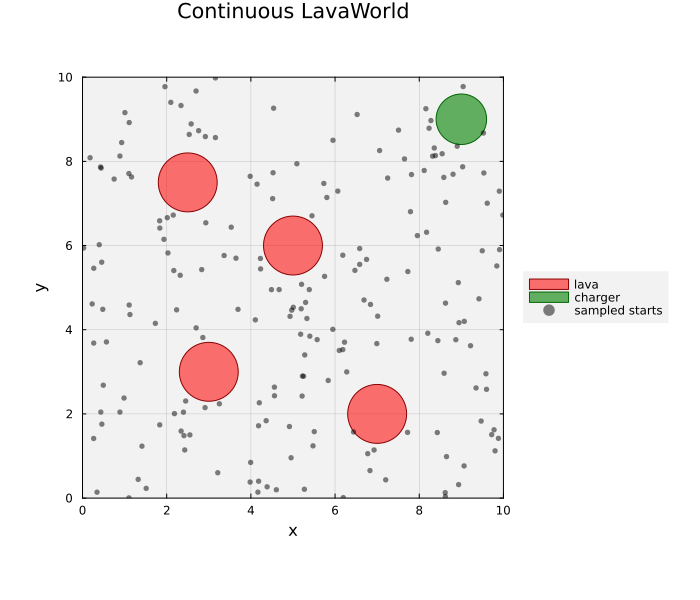

In [5]:
let
    Random.seed!(11)
    samples = [initial_state(worldcontext) for _ in 1:200]
    sx = [s[1] for s in samples]
    sy = [s[2] for s in samples]

    p = plot(; xlim = (0, LX), ylim = (0, LY), aspect_ratio = :equal,
        title = "Continuous LavaWorld",
        xlabel = "x", ylabel = "y",
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :outerright)

    θ = range(0, 2π; length = 60)
    for (i, (lx, ly)) in enumerate(LAVA_POS)
        plot!(p, lx .+ LAVA_RADIUS .* cos.(θ), ly .+ LAVA_RADIUS .* sin.(θ);
            seriestype = :shape, fillcolor = :red, linecolor = :darkred,
            fillalpha = 0.55, label = (i == 1 ? "lava" : nothing))
    end
    cx, cy = CHARGER_POS
    plot!(p, cx .+ CHARGER_RADIUS .* cos.(θ), cy .+ CHARGER_RADIUS .* sin.(θ);
        seriestype = :shape, fillcolor = :green, linecolor = :darkgreen,
        fillalpha = 0.6, label = "charger")

    scatter!(p, sx, sy; ms = 3, msw = 0, c = :black, alpha = 0.5,
        label = "sampled starts")

    plot(p; size = (700, 600),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What changes when we go from grid LavaWorld to continuous LavaWorld?__ In the L13a tabular setting, the agent's state was a single integer $1,\ldots,nstates$ and a Q-table held one row per cell. (a) Why does adding velocity components $(v_{x}, v_{y})$ kill the tabular approach even before we make $(x, y)$ continuous? (b) If you discretized $(x, y, v_{x}, v_{y})$ at $20$ levels per axis, how many states would the Q-table have, and how many environment interactions would you need before every cell saw at least one update? Compare that to the number of parameters in the small `STATE_DIM → HIDDEN → |𝒜|` Q-network we are about to build.

___

## Task 2: Assemble and train the DQN agent
In this task, we build the four moving parts of a DQN agent — a main Q-network $Q_{\theta}$, a target Q-network $Q'_{\theta^{-}}$, a discrete action set $\mathcal{A}$, and a fixed-size circular replay buffer $\mathcal{B}$ of $(s, a, r, s', \mathrm{done})$ tuples — and then run the DQN training loop on the world we built in Task 1.

> __Network architecture and what each piece is for.__
>
> The Q-network is a small MLP `Dense(STATE_DIM → HIDDEN, relu) → Dense(HIDDEN → HIDDEN, relu) → Dense(HIDDEN → |𝒜|)`. The output is a length-5 vector of Q-values, one per action; we never apply a softmax because we care about argmax-Q, not a probability distribution over actions. The target network has the *same* architecture but its parameters are frozen between syncs and used only to compute bootstrap targets, exactly as in the L16a lecture algorithm:
> $$y_{i} = r_{i} + \gamma\,(1 - d_{i})\,\max_{a^{\prime}\in\mathcal{A}}\,[Q^{\prime}_{\theta^{-}}(s^{\prime}_{i})]_{a^{\prime}}.$$
> The factor $(1 - d_{i})$ zeros the bootstrap on terminal transitions, which is why our `world(...)` returns a `done` flag and our replay tuple stores it.
>
> The replay buffer is a `CircularBuffer` of capacity `BUFFER_SIZE`. New transitions append; once it is full, the oldest tuple is evicted FIFO. Training does not start at step 1; the agent first runs a *warm-up phase* until $|\mathcal{B}|\geq$ `WARMUP`, populating the buffer with off-policy random transitions before any gradient is taken. This is the practical detail the lecture flagged: without warm-up, the first mini-batches are dominated by a handful of correlated initial transitions and the network locks onto a degenerate Q-function.

The code block below stores the main and target networks in `M::Chain` and `T::Chain`, and the assembled agent in `agent::MyDQNLearningAgentModel`.

In [6]:
M, T, agent = let
    Random.seed!(0xDA1A)
    make_qnet() = Chain(
        Dense(STATE_DIM, HIDDEN, relu),
        Dense(HIDDEN,   HIDDEN, relu),
        Dense(HIDDEN,   5),                          # 5 = |𝒜|: +x, −x, +y, −y, coast
    )
    main = make_qnet()
    target = make_qnet()
    Flux.loadmodel!(target, Flux.state(main))        # θ⁻ ← θ at initialization

    a = build(MyDQNLearningAgentModel, (
        mainnetwork      = main,
        targetnetwork    = target,
        thrust           = THRUST,
        number_of_inputs = STATE_DIM,
    ))
    (main, target, a)
end;

### Inspect the agent's state
Three quick checks: (i) the action dictionary has five entries, one per discrete thrust direction; (ii) the main and target networks share architecture and parameter count; (iii) the main network maps a 4-vector state to a length-5 Q-value vector at random init.

In [7]:
let
    Random.seed!(3)
    @info "agent shape" K = agent.number_of_actions input_dim = agent.number_of_inputs
    df_actions = DataFrame(
        idx = collect(keys(agent.actions)),
        Δvx = [v[1] for v in values(agent.actions)],
        Δvy = [v[2] for v in values(agent.actions)],
    )
    sort!(df_actions, :idx)
    pretty_table(df_actions;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    s = Float32[5.0f0, 5.0f0, 0.0f0, 0.0f0]
    q_main   = M(s)
    q_target = T(s)
    @info "random-init Q-values at s=(5,5,0,0)" q_main = round.(q_main; digits = 3) q_target = round.(q_target; digits = 3) main_minus_target = round.(q_main .- q_target; digits = 3)
    df_actions
end

┌ Info: agent shape
│   K = 5
│   input_dim = 4
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:3


 ------- --------- ---------
    idx       Δvx       Δvy 
  Int64   Float32   Float32 
 ------- --------- ---------
      1       0.4       0.0
      2      -0.4       0.0
      3       0.0       0.4
      4       0.0      -0.4
      5       0.0       0.0
 ------- --------- ---------


┌ Info: random-init Q-values at s=(5,5,0,0)
│   q_main = Float32[-0.436, -0.077, 0.21, 0.132, -0.019]
│   q_target = Float32[-0.436, -0.077, 0.21, 0.132, -0.019]
│   main_minus_target = Float32[0.0, 0.0, 0.0, 0.0, 0.0]
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sZmlsZQ==.jl:17


Row,idx,Δvx,Δvy
,Int64,Float32,Float32
1,1,0.4,0.0
2,2,-0.4,0.0
3,3,0.0,0.4
4,4,0.0,-0.4
5,5,0.0,0.0


### Things to think about
* __Why two networks instead of one?__ The bootstrap target $y_{i} = r_{i} + \gamma\,(1 - d_{i})\,\max_{a'}\,Q'(s'_{i}, a')$ uses $Q'$ on the right-hand side and we update $Q$ on the left-hand side; if both came from the same network, every gradient step on the loss would also move the target. (a) What kind of training instability does this create, in plain language? (b) Why does freezing $\theta^{-}$ for `TARGET_SYNC` steps before copying $\theta^{-} \leftarrow \theta$ fix it without changing the *fixed point* of training?

### Train the agent
With the agent assembled, we run the DQN training loop for `EPISODES` episodes of up to `MAX_STEPS_EP` steps each, watch the per-episode return climb, and break the terminal kind down by episode (charger / lava / timeout) to confirm the agent is actually learning to reach the goal rather than just learning to avoid lava.

> __What `learn(...)` does, in one paragraph.__
>
> For each episode, we sample a fresh start state and step the world up to `MAX_STEPS_EP` times. At every step we choose an action with a $t^{-1/3}$-decayed ε-greedy rule (with floor `EPS_FLOOR`), execute it in the world, and store the resulting `(s, a, r, s′, done)` tuple in the replay buffer. Once the buffer is at least `WARMUP` full, every step we draw a mini-batch of `MINIBATCH` transitions, compute the bootstrap target with the *target* network, and take a single Adam gradient step on the main network so that $[Q_{\theta}(s_{i})]_{a_{i}}$ moves toward $y_{i}$. Every `TARGET_SYNC` global steps we copy $\theta^{-} \leftarrow \theta$. If `done` is true, the episode ends early and we move on to the next start state.

The code block below stores the trained agent (with replay buffer) back into `agent::MyDQNLearningAgentModel` and the per-episode diagnostics in `history::NamedTuple` for use in subsequent cells.

In [8]:
agent, history = let
    Random.seed!(2026)
    learn(agent, world;
        context              = worldcontext,
        maxnumberofsteps     = MAX_STEPS_EP,
        numberofepisodes     = EPISODES,
        γ                    = DISCOUNT,
        α                    = LR,
        maxreplaybuffersize  = BUFFER_SIZE,
        warmupsize           = WARMUP,
        trainfreq            = 1,
        parameterupdatefreq  = TARGET_SYNC,
        minibatchsize        = MINIBATCH,
        ε_floor              = EPS_FLOOR,
        verbose              = true)
end;

┌ Info: DQN episode
│   episode = 1
│   return_ = -10.0
│   length = 200
│   terminal = timeout
│   buffer = 200
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:211
┌ Info: DQN episode
│   episode = 30
│   return_ = -101.35
│   length = 28
│   terminal = lava
│   buffer = 3248
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:211
┌ Info: DQN episode
│   episode = 60
│   return_ = 99.55
│   length = 10
│   terminal = charger
│   buffer = 5000
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:211
┌ Info: DQN episode
│   episode = 90
│   return_ = 92.35
│   length = 154
│   terminal = charger
│   buffer = 6837
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring

### Reward curve and terminal-kind histogram
The left panel plots the per-episode return $G_{e} = \sum_{t}r_{t}$ together with a 25-episode running mean. With reward shaping `(STEP_COST, LAVA_REWARD, CHARGER_REWARD)` chosen as above, an episode that ends in the charger has return ≳ +90, an episode that ends in lava has return ≲ −100, and a timeout has return ≈ −10. The right panel breaks the episodes into ten-episode bins and shows the fraction that ended at the charger, in lava, or in a timeout — the curve we want to see is the green (charger) fraction climbing past the red (lava) and grey (timeout) fractions over the course of training.

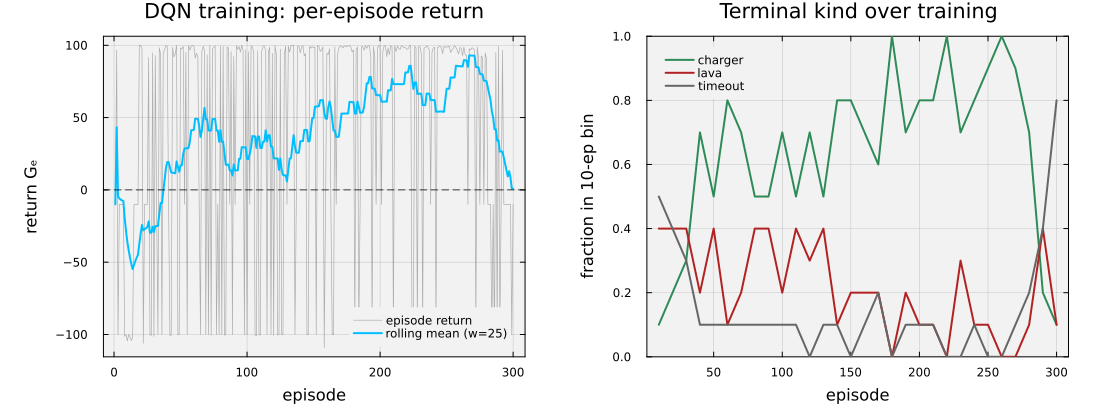

In [9]:
let
    G = history.episode_returns
    n = length(G)
    w = 25
    rolling = [mean(@view G[max(1, i - w + 1):i]) for i in 1:n]

    p_curve = plot(1:n, G;
        c = :gray, lw = 0.7, alpha = 0.6, label = "episode return",
        xlabel = "episode", ylabel = "return Gₑ",
        title = "DQN training: per-episode return",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p_curve, 1:n, rolling; c = :deepskyblue, lw = 2.0, label = "rolling mean (w=$w)")
    hline!(p_curve, [0.0]; c = :black, ls = :dash, lw = 0.7, label = nothing)

    bin = 10
    nb = cld(n, bin)
    f_chg  = zeros(Float64, nb)
    f_lava = zeros(Float64, nb)
    f_to   = zeros(Float64, nb)
    for i in 1:nb
        lo = (i - 1) * bin + 1
        hi = min(i * bin, n)
        slice = history.terminal_kind[lo:hi]
        L = length(slice)
        f_chg[i]  = count(==(:charger), slice) / L
        f_lava[i] = count(==(:lava),    slice) / L
        f_to[i]   = count(==(:timeout), slice) / L
    end
    bx = (1:nb) .* bin
    p_term = plot(bx, f_chg; lw = 2.0, c = :seagreen, label = "charger",
        xlabel = "episode", ylabel = "fraction in $bin-ep bin",
        title = "Terminal kind over training",
        ylim = (0, 1.0),
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p_term, bx, f_lava; lw = 2.0, c = :firebrick, label = "lava")
    plot!(p_term, bx, f_to;   lw = 2.0, c = :gray40,    label = "timeout")

    plot(p_curve, p_term; layout = (1, 2), size = (1100, 420),
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Read the two panels together.__ (a) Roughly when does the rolling mean cross zero, and what does that crossover correspond to in the terminal-kind plot? (b) Even after training, the lava fraction does not go all the way to zero — name two reasons rooted in what we built (the actuator noise and the ε-floor are not the only ones).

___

## Task 3: Visualize the learned policy and run a closed-loop rollout
In this task, we look at *what the agent learned* in two ways. First, we evaluate the greedy policy on a regular grid of positions (with $v_{x} = v_{y} = 0$) to get the action-color field over the board, plus the max-Q heatmap that should peak near the charger and trough near each lava pit. Second, we drop the trained agent into the world from a deliberately hard starting state and watch its trajectory, comparing it against an untrained baseline.

The code block below stores the policy-field arrays in `pf::NamedTuple` (with fields `xs`, `ys`, `A`, `Q`) for use in the heatmap below.

In [10]:
pf = let
    xs, ys, A, Q = greedy_policy_field(agent, worldcontext; nx = 40, ny = 40,
        v = (0.0f0, 0.0f0))
    (xs = xs, ys = ys, A = A, Q = Q)
end;

### Greedy policy field and max-Q heatmap
The left panel colors each grid cell by the index of the greedy action at that cell (with $v = 0$): one color per thrust direction, plus one for *coast*. A well-trained agent should show clean attractor regions pointing toward the charger and steering away from each lava disk. The right panel is the max-Q heatmap $V(s) = \max_{a}Q(s, a)$ at the same grid; with our reward scale it should be highest near the charger (positive) and lowest in lava neighborhoods (very negative).

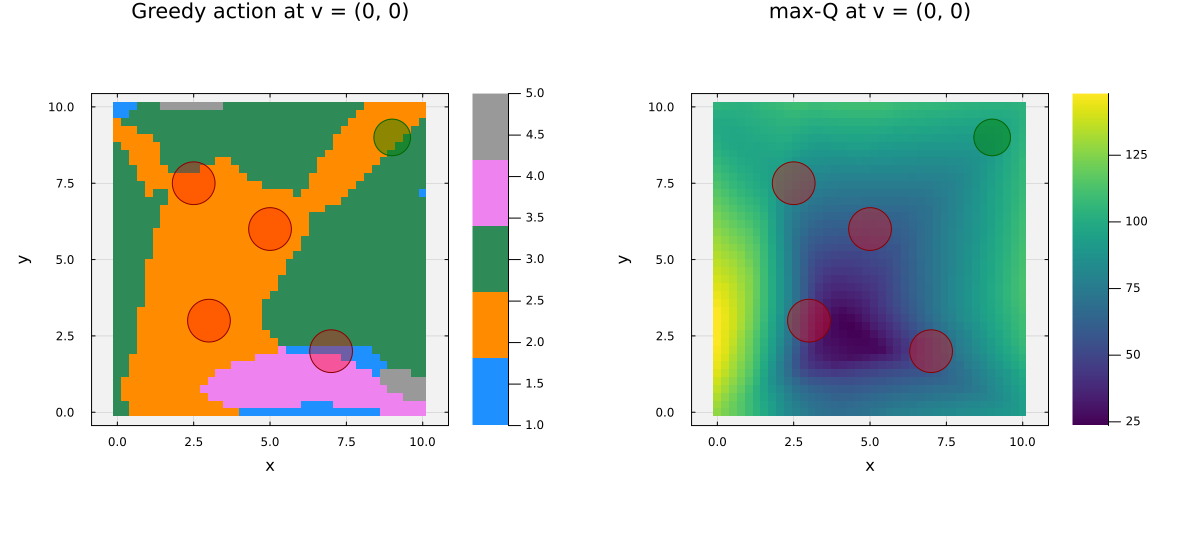

In [11]:
let
    action_palette = [:dodgerblue, :darkorange, :seagreen, :violet, :gray60]
    action_label   = ["+x",         "−x",         "+y",       "−y",     "coast"]

    A = pf.A
    p_pol = heatmap(pf.xs, pf.ys, A';
        c = cgrad(action_palette, 5; categorical = true), clims = (1, 5),
        colorbar_ticks = (1:5, action_label),
        xlabel = "x", ylabel = "y",
        title = "Greedy action at v = (0, 0)",
        aspect_ratio = :equal, bg = "gray95",
        background_color_outside = "white", framestyle = :box)

    p_v = heatmap(pf.xs, pf.ys, pf.Q';
        c = :viridis,
        xlabel = "x", ylabel = "y",
        title = "max-Q at v = (0, 0)",
        aspect_ratio = :equal, bg = "gray95",
        background_color_outside = "white", framestyle = :box)

    θ = range(0, 2π; length = 60)
    for p in (p_pol, p_v)
        for (lx, ly) in LAVA_POS
            plot!(p, lx .+ LAVA_RADIUS .* cos.(θ), ly .+ LAVA_RADIUS .* sin.(θ);
                seriestype = :shape, fillcolor = :red, linecolor = :darkred,
                fillalpha = 0.35, label = nothing)
        end
        cx, cy = CHARGER_POS
        plot!(p, cx .+ CHARGER_RADIUS .* cos.(θ), cy .+ CHARGER_RADIUS .* sin.(θ);
            seriestype = :shape, fillcolor = :green, linecolor = :darkgreen,
            fillalpha = 0.45, label = nothing)
    end

    plot(p_pol, p_v; layout = (1, 2), size = (1200, 540),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Closed-loop rollout from a hard start
We drop the agent at $(x, y) = (0.5, 0.5)$ with zero velocity — opposite corner from the charger, with three lava disks between the start and the goal — and let it run greedy. For comparison, we also run a *fresh* untrained network from the same state. The good agent should thread its way to the charger; the random agent should wander or die in lava.

In [12]:
trained_traj, random_traj = let
    Random.seed!(99)
    s0 = Float32[0.5f0, 0.5f0, 0.0f0, 0.0f0]
    trained = rollout(agent, world; context = worldcontext,
        max_steps = 400, greedy = true, s0 = s0)

    # untrained baseline: brand-new random network in a throwaway agent
    Random.seed!(99)
    fresh_main = Chain(
        Dense(STATE_DIM, HIDDEN, relu),
        Dense(HIDDEN,   HIDDEN, relu),
        Dense(HIDDEN,   5),
    )
    fresh_target = Chain(
        Dense(STATE_DIM, HIDDEN, relu),
        Dense(HIDDEN,   HIDDEN, relu),
        Dense(HIDDEN,   5),
    )
    fresh_agent = build(MyDQNLearningAgentModel, (
        mainnetwork = fresh_main, targetnetwork = fresh_target,
        thrust = THRUST, number_of_inputs = STATE_DIM,
    ))
    Random.seed!(99)
    rand_roll = rollout(fresh_agent, world; context = worldcontext,
        max_steps = 400, greedy = true, s0 = s0)

    @info "rollout summary" trained_terminal = trained.terminal trained_steps = length(trained.actions) trained_return = round(trained.total_return; digits = 2) random_terminal = rand_roll.terminal random_steps = length(rand_roll.actions) random_return = round(rand_roll.total_return; digits = 2)
    (trained, rand_roll)
end;

┌ Info: rollout summary
│   trained_terminal = timeout
│   trained_steps = 400
│   trained_return = -20.0
│   random_terminal = timeout
│   random_steps = 400
│   random_return = -20.0
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X40sZmlsZQ==.jl:27


### Trajectories on the board
Both trajectories are overlaid on the same board, with the start marked as a black dot and the terminal point as a star (green if charger, red if lava, gray if timeout).

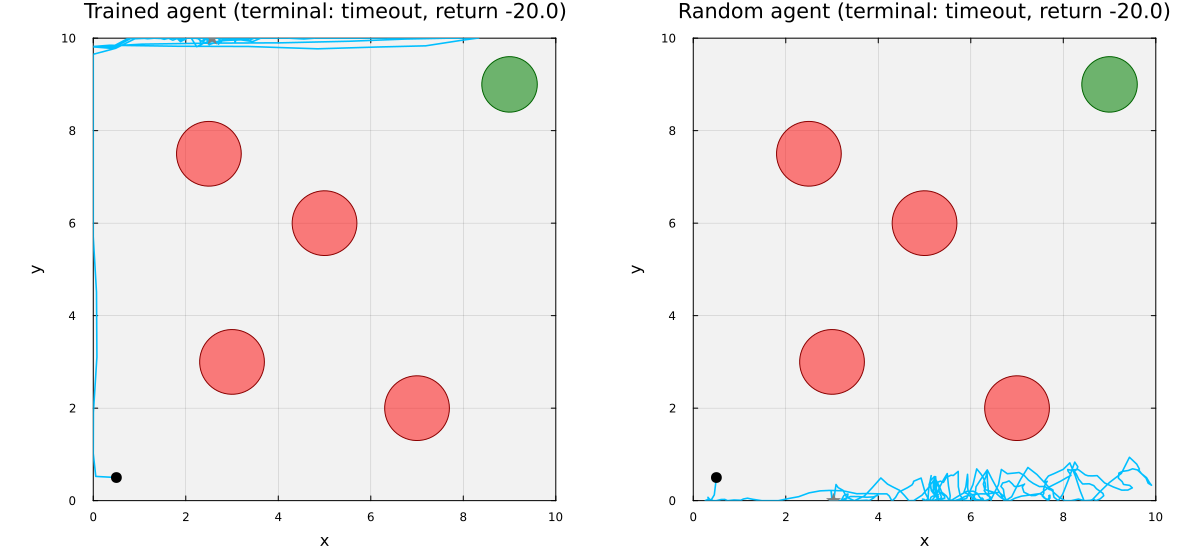

In [13]:
let
    function draw_board!(p)
        θ = range(0, 2π; length = 60)
        for (lx, ly) in LAVA_POS
            plot!(p, lx .+ LAVA_RADIUS .* cos.(θ), ly .+ LAVA_RADIUS .* sin.(θ);
                seriestype = :shape, fillcolor = :red, linecolor = :darkred,
                fillalpha = 0.5, label = nothing)
        end
        cx, cy = CHARGER_POS
        plot!(p, cx .+ CHARGER_RADIUS .* cos.(θ), cy .+ CHARGER_RADIUS .* sin.(θ);
            seriestype = :shape, fillcolor = :green, linecolor = :darkgreen,
            fillalpha = 0.55, label = nothing)
    end
    function term_color(sym)
        sym == :charger && return :green
        sym == :lava    && return :red
        return :gray
    end

    function trajplot(roll; title)
        p = plot(; xlim = (0, LX), ylim = (0, LY), aspect_ratio = :equal,
            xlabel = "x", ylabel = "y", title = title,
            bg = "gray95", background_color_outside = "white",
            framestyle = :box, legend = false)
        draw_board!(p)
        plot!(p, roll.xs, roll.ys; lw = 1.6, c = :deepskyblue, label = nothing)
        scatter!(p, [roll.xs[1]], [roll.ys[1]]; ms = 6, msw = 0, c = :black, label = nothing)
        scatter!(p, [roll.xs[end]], [roll.ys[end]]; ms = 8, msw = 0,
            c = term_color(roll.terminal), marker = :star5, label = nothing)
        p
    end

    p1 = trajplot(trained_traj;
        title = "Trained agent (terminal: $(trained_traj.terminal), return $(round(trained_traj.total_return; digits=1)))")
    p2 = trajplot(random_traj;
        title = "Random agent (terminal: $(random_traj.terminal), return $(round(random_traj.total_return; digits=1)))")

    plot(p1, p2; layout = (1, 2), size = (1200, 560),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Use the policy field to predict the trajectory.__ Look at the colored arrows in the greedy-action heatmap and trace what the agent *would* do starting from $(0.5, 0.5)$, ignoring momentum. Then look at the actual trajectory plotted above. (a) Where do the two diverge most, and is momentum helping or hurting at that point? (b) The max-Q heatmap should be lowest right at the lava centers and high near the charger; is the gradient between them smooth, or is there a visible *moat* of low Q-values around each pit?

___

## Summary
We took the LavaWorld grid problem from CHEME-5800, replaced the discrete cell index with a continuous $\mathbb{R}^{4}$ state $(x, y, v_{x}, v_{y})$ that includes momentum, and trained a DQN agent to navigate it. Tabular Q-learning is dead in this regime; a neural Q-function with a replay buffer and a delayed target network is exactly the tool the L16a lecture said it would be.

> __Key Takeaways:__
>
> * **Continuous state kills the Q-table; a neural Q-function fixes it:** Going from a $30\times 30$ grid to $\mathbb{R}^{4}$ blows up the state space combinatorially, but the Q-network has a *fixed* parameter count and shares weights across the entire continuous board. The agent generalizes to states it never visited during training, and the policy field is smooth.
> * **The replay buffer and the target network are the two stabilizers, just as advertised:** Random mini-batches from `BUFFER_SIZE`-deep buffer break the temporal correlation between consecutive transitions; freezing $\theta^{-}$ for `TARGET_SYNC` steps before each sync keeps the bootstrap target from chasing $\theta$. The `done` flag in our replay tuples is what zeros the bootstrap on terminal transitions and makes the target value land on the actual reward at the charger and at lava.
> * **Reward shaping matters more than network architecture for small problems:** Our `(STEP_COST, LAVA_REWARD, CHARGER_REWARD)` choices were what determined whether the agent learns to seek the goal or just learns to stand still. Bumping `STEP_COST` further negative pushes the agent to be aggressive; making it too negative makes the agent prefer the lava as a faster way to end the episode.

Two natural extensions, both inside the framework we built:
* Replace uniform sampling from the replay buffer with *prioritized* experience replay (sample with probability proportional to $|y_{i} - Q_{\theta}(s_{i}, a_{i})|$); see whether the agent learns to avoid lava faster.
* Move from a discrete five-action thrust set to a continuous action space and switch the algorithm from DQN to DDPG; the same `world(...)` function still applies, only the actor/critic structure changes.

**That's it for the semester. Thank you for the engagement, the questions, and the code.**
___